In [1]:
from FlashDroughts import KDEhistogram,DroughtDetection, FlashDrought
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import shapefile
from shapely.geometry import shape
import pandas as pd
from matplotlib.animation import FuncAnimation,  PillowWriter
import ast
from IPython.display import HTML 
from IPython.display import Image
from datetime import datetime, timedelta

Creates a distribution graph based off of the conditions of:
- 2 of the 3 variables report the flash drought
- contains a 2 week buffer on either side of the onset date

Insert County csv

In [2]:
# For the Northeast centers of each county
df = pd.read_csv('Counties3.csv')

Clean Code:

In [3]:

# Clean function
def clean_coord(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    val = re.sub(r'[–—−]', '-', val)  # replace Unicode dashes with -
    val = val.replace('°', '')        # remove degree symbol
    try:
        return float(val)
    except ValueError:
        return np.nan

# Apply to both columns
df['lat'] = df['lat'].apply(clean_coord)
df['lon'] = df['lon'].apply(clean_coord)
df = df.drop(columns=['Unnamed: 4','Unnamed: 5','Unnamed: 6','Unnamed: 7','Unnamed: 8','Unnamed: 9','Unnamed: 10','Unnamed: 11','Unnamed: 12','Unnamed: 13'])
locations = df[['state', 'county', 'lat', 'lon']].to_dict(orient='records')

Choose:
- either data grouped per 2 weeks or 4 weeks for PET and Precip
- detection timescale of either 2 weeks or 4 weeks
- start date of given time period

In [7]:
grouped = 4
detection = 'four_week_onset' # or 'two_week_onset'
start_date = '2002-03-01'

Create combined Dataframe:
- takes around 30 min - 1 hour to run

In [10]:
all_onsets = []

for loc in locations:
    state = loc['state']
    county = loc['county']
    lat = loc['lat']
    lon = loc['lon']    

    pet = DroughtDetection(lat=lat, lon=lon, start_date=start_date, rolling_column='pet', weeks=grouped, residual_column='pet')
    precip = DroughtDetection(lat=lat, lon=lon, start_date=start_date, rolling_column='precip', weeks=grouped, residual_column=None)
    vwc = DroughtDetection(lat=lat, lon=lon, start_date=start_date, rolling_column='vwc', weeks=1, residual_column=None)

    datasets = [
        ("pet",    pet,    f'pet {grouped} rolling Residuals', ['pearson']),
        ("precip", precip, f'precip {grouped} rolling',        ['pearson']),
        ("vwc",    vwc,    'vwc 1 rolling',                    ['normal']),
    ]
    for name, obj, column, funcs in datasets:
        detect_func = getattr(obj, detection)   
        onset_df = detect_func(column=column, functions=funcs)

        if not onset_df.empty:
            onset_df = onset_df.copy()
            onset_df['State'] = state
            onset_df['County'] = county
            onset_df['lat'] = lat
            onset_df['lon'] = lon
            onset_df['source'] = name  
            all_onsets.append(onset_df)

final_onset_df = pd.concat(all_onsets, ignore_index=True)
final_onset_df

,onset_date,end_date,onset pet 4 rolling Residuals category,end pet 4 rolling Residuals category,onset pet 4 rolling Residuals,end pet 4 rolling Residuals,function,State,County,lat,lon,source,onset precip 4 rolling category,end precip 4 rolling category,onset precip 4 rolling,end precip 4 rolling,onset vwc 1 rolling category,end vwc 1 rolling category,onset vwc 1 rolling,end vwc 1 rolling
0,2010-04-20,2010-05-18,0.0,2.0,-0.779777,-1.584294,pearson,CT,Fairfield,41.228103,-73.366757,pet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-06-22,2010-07-20,0.0,3.0,-0.541211,-1.981516,pearson,CT,Fairfield,41.228103,-73.366757,pet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-04-03,2012-05-01,0.0,2.0,-0.535599,-1.334091,pearson,CT,Fairfield,41.228103,-73.366757,pet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015-08-11,2015-09-08,1.0,4.0,-0.988744,-2.086742,pearson,CT,Fairfield,41.228103,-73.366757,pet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-08-09,2016-09-06,1.0,3.0,-1.226620,-2.029544,pearson,CT,Fairfield,41.228103,-73.366757,pet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,2005-04-19,2005-05-17,NaN,NaN,NaN,NaN,normal,CT,Litchfield,41.791897,-73.235428,vwc,NaN,NaN,NaN,NaN,1.0,3.0,-1.068345,-1.750963
67,2012-03-20,2012-04-17,NaN,NaN,NaN,NaN,normal,CT,Litchfield,41.791897,-73.235428,vwc,NaN,NaN,NaN,NaN,1.0,3.0,-0.840805,-1.978502
68,2013-04-09,2013-05-07,NaN,NaN,NaN,NaN,normal,CT,Litchfield,41.791897,-73.235428,vwc,NaN,NaN,NaN,NaN,1.0,3.0,-0.840805,-1.978502
69,2015-05-05,2015-06-02,NaN,NaN,NaN,NaN,normal,CT,Litchfield,41.791897,-73.235428,vwc,NaN,NaN,NaN,NaN,0.0,3.0,-0.613266,-1.978502


Create dataframe of combined onsets:
- 2 week buffer for onset start time windows

In [11]:
final_onset_df['onset_date'] = pd.to_datetime(final_onset_df['onset_date'])
multi_source_onsets = []
grouped = final_onset_df.groupby(['State', 'County', 'lat', 'lon'])

for (state, county, lat, lon), group in grouped:
    group = group.copy()

    for i, row in group.iterrows():
        current_date = row['onset_date']
        source = row['source']

        window_start = current_date - timedelta(weeks=2)
        window_end = current_date + timedelta(weeks=2)

        matches = group[(group['onset_date'] >= window_start) &
                        (group['onset_date'] <= window_end)]

        matched_sources = matches['source'].unique()

        if len(matched_sources) >= 2:
            avg_onset = matches['onset_date'].mean()
            multi_source_onsets.append({
                'State': state,
                'County': county,
                'lat': lat,
                'lon': lon,
                'avg_onset_date': avg_onset,
                'sources': list(matched_sources),
                'num_sources': len(matched_sources),
                'month': avg_onset.strftime('%B')
            })

df_onset_combined = pd.DataFrame(multi_source_onsets).drop_duplicates(subset=['State', 'County', 'lat', 'lon', 'avg_onset_date'])

In [12]:
def get_all_modes(series):
    counts = series.value_counts()
    max_count = counts.max()
    return counts[counts == max_count].index.tolist()


most_common_months = df_onset_combined.groupby(['State', 'County'])['month'].agg(get_all_modes).reset_index(name='most common months')
onset = df_onset_combined.groupby(['State', 'County']).size().reset_index(name='num_onsets')
onset = onset.merge(most_common_months, on=['State', 'County'], how='left')
all_counties = final_onset_df[['State', 'County']].drop_duplicates()
onset_full = all_counties.merge(onset, on=['State', 'County'], how='left')
onset_full['num_onsets'] = onset_full['num_onsets'].fillna(0).astype(int)

Create distribution Graphs

In [13]:
df = onset_full

# Strip spaces and lowercase for clean matching
df['County'] = df['County'].str.lower().str.strip()
df['State'] = df['State'].str.lower().str.strip()

# Add combined key for matching
df['county_state'] = df['County'] + '_' + df['State']

statefp_to_abbr = {
    '09': 'ct', '23': 'me', '25': 'ma', '33': 'nh', '34': 'nj',
    '36': 'ny', '42': 'pa', '44': 'ri', '50': 'vt', '24': 'md',
    '54': 'wv', '10': 'de'
}

# Read shapefile
sf = shapefile.Reader("/Users/adriennekirk/Downloads/tl_2020_us_county/tl_2020_us_county.shp")
records = sf.shapeRecords()

Optional: Set min and max for gradient scale and choose graph title

In [14]:
value_col = 'num_onsets'
vmin = df[value_col].min()
vmax = df[value_col].max()
title = 'County Flash Droughts by 2cat/4wk' #'County Flash Droughts by 2cat/2wk'

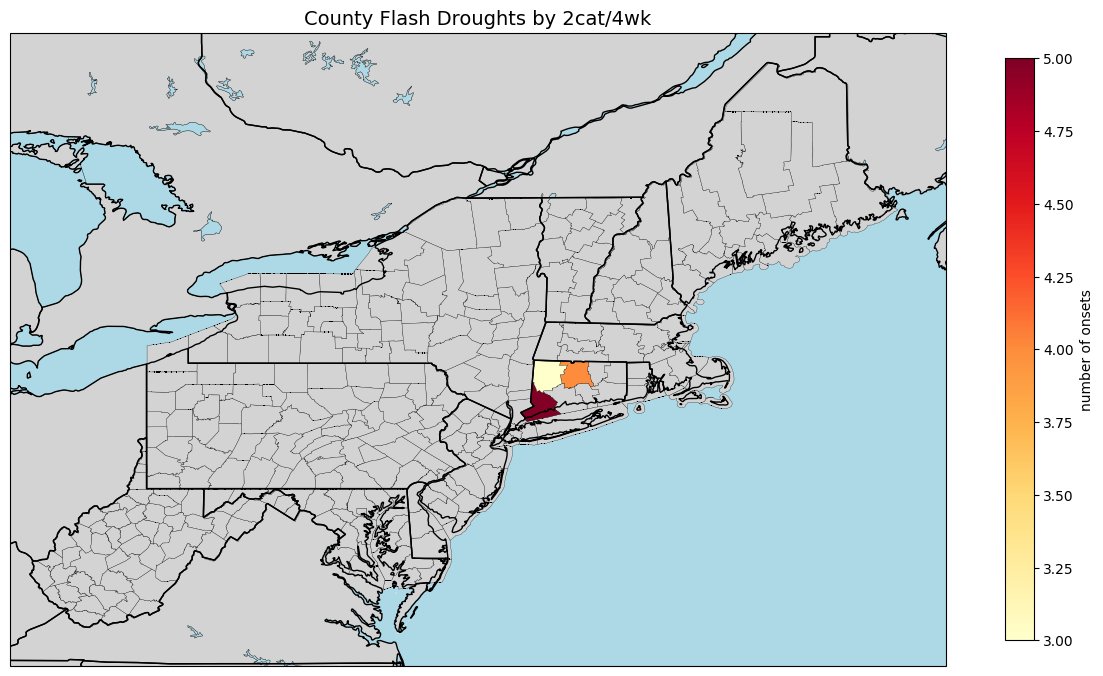

In [15]:
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('YlOrRd', 256)

fig, ax = plt.subplots(figsize=(12, 10),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-83, -66, 36.5, 48], crs=ccrs.PlateCarree())


for rec in records:
    attrs = rec.record.as_dict()
    county_name = attrs['NAME'].lower().strip()
    statefp = attrs['STATEFP']
    state_abbr = statefp_to_abbr.get(statefp, None)
    if not state_abbr:
        continue

    key = f"{county_name}_{state_abbr}"
    geom = shape(rec.shape.__geo_interface__)

    if key in df['county_state'].values:
        value = df.loc[df['county_state'] == key, value_col].values[0]
        color = cmap(norm(value))
    else:
        color = 'lightgrey'

    ax.add_geometries([geom], crs=ccrs.PlateCarree(),
                      facecolor=color, edgecolor='black', linewidth=0.2)


sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label= 'number of onsets', shrink=0.6)


ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', zorder=0)
ax.add_feature(cfeature.LAKES, facecolor='lightblue', edgecolor='black', linewidth=0.3, zorder=1)
ax.add_feature(cfeature.STATES, linewidth=1, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='none')

plt.title(title, fontsize=14)
plt.tight_layout()
plt.show()